In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import jarque_bera, skew, kurtosis

In [2]:
# Load the Bars from path
paths = {
  "Tick": Path("../data/es_tick_bars.csv"),
  "Volume": Path("../data/es_volume_bars.csv"),
  "Dollar": Path("../data/es_dollar_bars.csv")
}

# Notify if files are missing
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing files: {', '.join(missing)}")


# read the CSV files into DataFrames
tick_bars = pd.read_csv(paths["Tick"], parse_dates=["timestamp"])
volume_bars = pd.read_csv(paths["Volume"], parse_dates=["timestamp"])
dollar_bars = pd.read_csv(paths["Dollar"], parse_dates=["timestamp"])

# print the bars
print("Tick:", len(tick_bars))
print("Volume:", len(volume_bars))
print("Dollar:", len(dollar_bars))

Tick: 150
Volume: 149
Dollar: 149


In [4]:
# Calculate the log returns

def add_log_returns(bars):
    return np.log(bars["close"] / bars["close"].shift(1)).dropna()

returns = {
    "Tick": add_log_returns(tick_bars),
    "Volume": add_log_returns(volume_bars),
    "Dollar": add_log_returns(dollar_bars)
}

for name, r in returns.items():
    print(name, "observations:", len(r))


Tick observations: 148
Volume observations: 147
Dollar observations: 147


In [5]:
# run jarque bera test
rows =[]

for name, r in returns.items():
    jb_stat = jarque_bera(r)

    rows.append({
        "Bar Type": name,
        "JB Statistic": jb_stat.statistic,
        "p-value": jb_stat.pvalue,
        "Skewness": skew(r),
        "Kurtosis": kurtosis(r, fisher=False)
    })

jb_stat_results = pd.DataFrame(rows).set_index("Bar Type")
jb_stat_results["Rank"] = jb_stat_results["JB Statistic"].rank(method="min")
jb_stat_results = jb_stat_results.sort_values("JB Statistic")

display(jb_stat_results)

,JB Statistic,p-value,Skewness,Kurtosis,Rank
Bar Type,,,,,
Volume,0.192032,0.908450,-0.040280,3.157677,1.0
Tick,0.571800,0.751338,0.132107,2.848622,2.0
Dollar,7.557588,0.022850,-0.212200,4.026536,3.0


In [6]:
# Identify the lowest test statistic
best_bar = jb_stat_results.index[0]

print("Lowest Jarque-Bera statistic bar type:", best_bar)
print()
print(jb_stat_results.loc[best_bar])

Lowest Jarque-Bera statistic bar type: Volume

JB Statistic    0.192032
p-value         0.908450
Skewness       -0.040280
Kurtosis        3.157677
Rank            1.000000
Name: Volume, dtype: float64


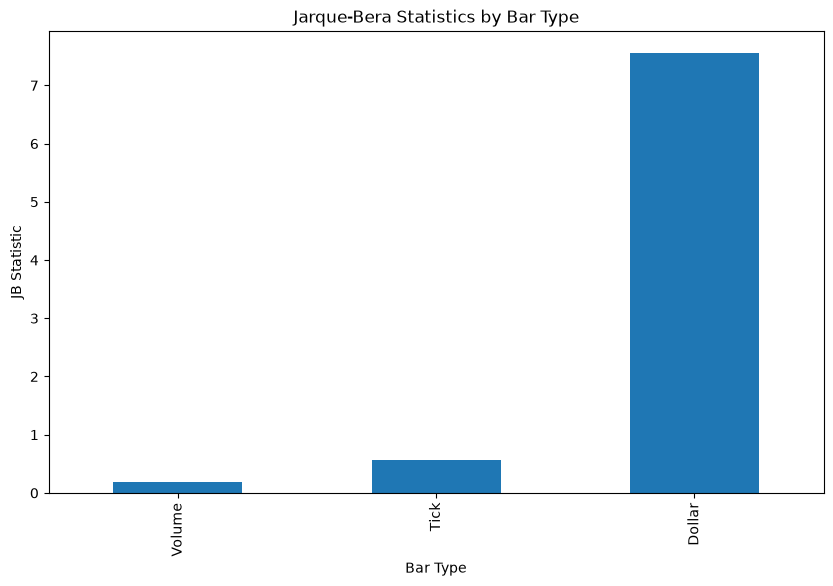

In [7]:
# plot the JB statistics
plt.figure(figsize=(10, 6))

jb_stat_results["JB Statistic"].sort_values().plot(kind="bar")
plt.title("Jarque-Bera Statistics by Bar Type")
plt.ylabel("JB Statistic")
plt.xlabel("Bar Type")
plt.show()

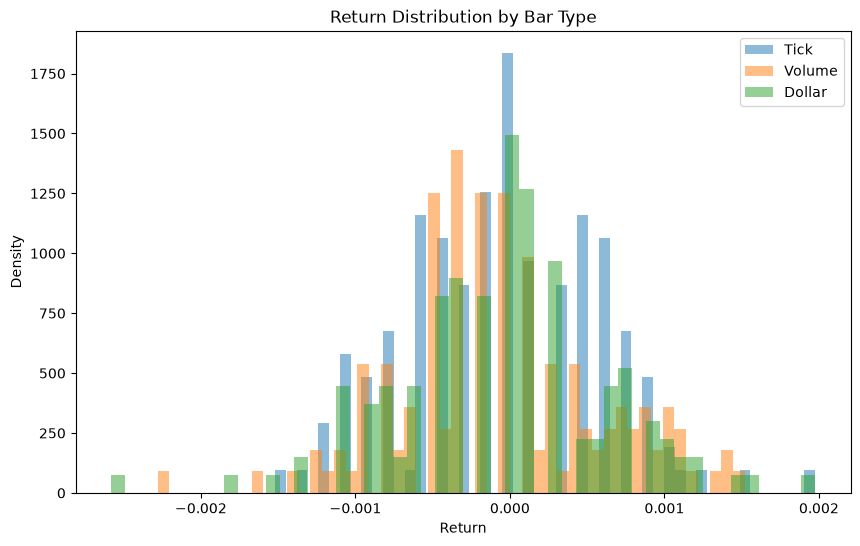

In [8]:
# compare return distribution
plt.figure(figsize=(10, 6))

for name, r in returns.items():
    plt.hist(r, bins=50, alpha=0.5, label=name, density=True)
plt.title("Return Distribution by Bar Type")
plt.xlabel("Return")
plt.ylabel("Density")
plt.legend()
plt.show()
